# YOLOv8n vs RF-DETR-B on 300 Person Images From COCO Dataset

This notebook compares two object detectors, base and fine-tuned, on a one-class COCO subset:
- YOLOv8n
- RF-DETR-B

Dataset policy used here:
- Source: COCO train2017 annotations
- Selected class: person
- Subset size: 300 images
- Split: 240 train / 60 val

## 1. Dependencies and Imports

In [1]:
import os
import importlib
import importlib.metadata as ilm
import sys
import subprocess

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

required = {
    "ultralytics": "ultralytics",
    "supervision": "supervision",
    "yaml": "pyyaml",
    "albumentations": "albumentations",
    "rfdetr": "rfdetr[train,loggers]",
}

for module_name, package_name in required.items():
    try:
        importlib.import_module(module_name)
    except ImportError:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name,
        ])

torch_version = ilm.version("torch")
torchvision_version = ilm.version("torchvision")
compat_map = {
    "2.7": "0.22",
    "2.8": "0.23",
}

torch_mm = ".".join(torch_version.split(".")[:2])
expected_tv = compat_map.get(torch_mm)

if expected_tv is not None and not torchvision_version.startswith(expected_tv + "."):
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        f"torchvision=={expected_tv}.*",
    ])
    torchvision_version = ilm.version("torchvision")

import albumentations as A
import ultralytics
import rfdetr
import supervision
import yaml

print(f"torch=={torch_version}")
print(f"torchvision=={torchvision_version}")
print(f"albumentations=={A.__version__}")
print(f"PYTORCH_ENABLE_MPS_FALLBACK={os.environ.get('PYTORCH_ENABLE_MPS_FALLBACK')}")
print("Dependency check complete.")

WARNING ⚠️ torchvision==0.23 is incompatible with torch==2.7.
Run 'pip install torchvision==0.22' to fix torchvision or 'pip install -U torch torchvision' to update both.
For a full compatibility table see https://github.com/pytorch/vision#installation
torch==2.8.0
torchvision==0.23.0
albumentations==2.0.8
PYTORCH_ENABLE_MPS_FALLBACK=1
Dependency check complete.


In [ ]:
import os
import random
import shutil
from pathlib import Path
from time import perf_counter

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")

import torch
from torchvision.ops import box_iou, nms

from ultralytics import YOLO, settings as yolo_settings

from rfdetr import RFDETRBase, RFDETRLarge

sns.set_theme(style="whitegrid")

DEVICE = "mps"

_test_boxes = torch.tensor([[0.0, 0.0, 10.0, 10.0], [1.0, 1.0, 9.0, 9.0]], device=DEVICE)
_test_scores = torch.tensor([0.9, 0.8], device=DEVICE)
_ = nms(_test_boxes, _test_scores, 0.5)

MODEL_COLORS = {
    "YOLOv8n": "blue",
    # "YOLOv8m": "cornflowerblue",
    "RF-DETR-B": "orange",
    # "RF-DETR-L": "tomato",
}

if (Path.cwd() / "data").exists():
    VISION_DIR = Path.cwd().resolve()
elif (Path.cwd() / "vision" / "data").exists():
    VISION_DIR = (Path.cwd() / "vision").resolve()
else:
    VISION_DIR = Path.cwd().resolve()

RUNS_ROOT = (VISION_DIR / "runs" / "model_compare").resolve()
RUNS_ROOT.mkdir(parents=True, exist_ok=True)
yolo_settings.update({"runs_dir": str((VISION_DIR / "runs").resolve())})

random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

[W420 14:46:57.010488000 MPSFallback.mm:14] Warning: The operator 'torchvision::nms' is not currently supported on the MPS backend and will fall back to run on the CPU. This may have performance implications. (function operator())


## 2. Dataset

In [3]:
import json
import shutil
import ssl
import zipfile
from urllib.request import Request, urlopen


def robust_download(url, dst_path, timeout=120):
    dst_path = Path(dst_path)
    dst_path.parent.mkdir(parents=True, exist_ok=True)

    candidates = [url]
    if url.startswith("https://"):
        candidates.append("http://" + url[len("https://"):])

    last_exc = None
    for candidate in candidates:
        try:
            req = Request(candidate, headers={"User-Agent": "Mozilla/5.0"})
            with urlopen(req, timeout=timeout) as resp, open(dst_path, "wb") as out:
                shutil.copyfileobj(resp, out)
            return candidate
        except Exception as exc:
            last_exc = exc

    if url.startswith("https://"):
        try:
            req = Request(url, headers={"User-Agent": "Mozilla/5.0"})
            insecure_ctx = ssl._create_unverified_context()
            with urlopen(req, context=insecure_ctx, timeout=timeout) as resp, open(dst_path, "wb") as out:
                shutil.copyfileobj(resp, out)
            return "https-unverified"
        except Exception as exc:
            last_exc = exc

    raise RuntimeError(f"Download failed for {url}: {last_exc}")


DATA_DIR = (VISION_DIR / "data").resolve()
DATA_DIR.mkdir(parents=True, exist_ok=True)

COCO_PERSON_ROOT = DATA_DIR / "coco_person300"
(COCO_PERSON_ROOT / "train" / "images").mkdir(parents=True, exist_ok=True)
(COCO_PERSON_ROOT / "train" / "labels").mkdir(parents=True, exist_ok=True)
(COCO_PERSON_ROOT / "valid" / "images").mkdir(parents=True, exist_ok=True)
(COCO_PERSON_ROOT / "valid" / "labels").mkdir(parents=True, exist_ok=True)

annotations_zip = DATA_DIR / "annotations_trainval2017.zip"
instances_json = DATA_DIR / "annotations" / "instances_train2017.json"

if not instances_json.exists():
    if not annotations_zip.exists():
        used = robust_download(
            "https://images.cocodataset.org/annotations/annotations_trainval2017.zip",
            annotations_zip,
        )
        print("Downloaded annotations via:", used)
    with zipfile.ZipFile(annotations_zip, "r") as zf:
        zf.extract("annotations/instances_train2017.json", path=DATA_DIR)

with open(instances_json, "r", encoding="utf-8") as f:
    coco = json.load(f)

person_cat_id = next(cat["id"] for cat in coco["categories"] if cat["name"] == "person")
person_anns = [
    ann for ann in coco["annotations"]
    if ann["category_id"] == person_cat_id
    and ann.get("iscrowd", 0) == 0
    and ann["bbox"][2] > 1
    and ann["bbox"][3] > 1
]

image_ids = sorted({ann["image_id"] for ann in person_anns})
PERSON_IMAGE_COUNT = 300
if len(image_ids) < PERSON_IMAGE_COUNT:
    raise RuntimeError(f"Not enough person images in COCO. Found {len(image_ids)}.")

rng = random.Random(42)
rng.shuffle(image_ids)
selected_ids = image_ids[:PERSON_IMAGE_COUNT]
selected_id_set = set(selected_ids)

split_idx = int(PERSON_IMAGE_COUNT * 0.8)
train_ids = set(selected_ids[:split_idx])
val_ids = set(selected_ids[split_idx:])

images_by_id = {img["id"]: img for img in coco["images"] if img["id"] in selected_id_set}
anns_by_image = {}
for ann in person_anns:
    img_id = ann["image_id"]
    if img_id in selected_id_set:
        anns_by_image.setdefault(img_id, []).append(ann)

for split_name in ["train", "valid"]:
    labels_dir = COCO_PERSON_ROOT / split_name / "labels"
    for lbl in labels_dir.glob("*.txt"):
        lbl.unlink()


def prepare_sample(img_id, split_name):
    image_info = images_by_id[img_id]
    file_name = Path(image_info["file_name"]).name
    image_dst = COCO_PERSON_ROOT / split_name / "images" / file_name

    if not image_dst.exists():
        coco_url = image_info.get("coco_url", f"https://images.cocodataset.org/train2017/{file_name}")
        coco_url = coco_url.replace("http://", "https://")
        robust_download(coco_url, image_dst)

    w = float(image_info["width"])
    h = float(image_info["height"])
    lines = []
    for ann in anns_by_image.get(img_id, []):
        x, y, bw, bh = ann["bbox"]
        xc = (x + bw / 2.0) / w
        yc = (y + bh / 2.0) / h
        bw_n = bw / w
        bh_n = bh / h
        if bw_n <= 0 or bh_n <= 0:
            continue
        lines.append(f"0 {xc:.6f} {yc:.6f} {bw_n:.6f} {bh_n:.6f}")

    label_dst = COCO_PERSON_ROOT / split_name / "labels" / f"{Path(file_name).stem}.txt"
    label_dst.write_text("\n".join(lines), encoding="utf-8")


for img_id in train_ids:
    prepare_sample(img_id, "train")
for img_id in val_ids:
    prepare_sample(img_id, "valid")

TRAIN_IMAGES_DIR = (COCO_PERSON_ROOT / "train" / "images").resolve()
VAL_IMAGES_DIR = (COCO_PERSON_ROOT / "valid" / "images").resolve()
TRAIN_LABELS_DIR = (COCO_PERSON_ROOT / "train" / "labels").resolve()
VAL_LABELS_DIR = (COCO_PERSON_ROOT / "valid" / "labels").resolve()

CLASS_NAMES = ["person"]
NUM_CLASSES = 1

COCO_PERSON_LOCAL_YAML = COCO_PERSON_ROOT / "coco_person300.yaml"
local_cfg = {
    "path": str(COCO_PERSON_ROOT),
    "train": "train/images",
    "val": "valid/images",
    "nc": 1,
    "names": {0: "person"},
}
with open(COCO_PERSON_LOCAL_YAML, "w", encoding="utf-8") as f:
    yaml.safe_dump(local_cfg, f, sort_keys=False)

RUNS_ROOT = (VISION_DIR / "runs" / "model_compare").resolve()
RUNS_ROOT.mkdir(parents=True, exist_ok=True)

print("Vision dir:", VISION_DIR)
print("COCO person root:", COCO_PERSON_ROOT)
print("Train images:", TRAIN_IMAGES_DIR)
print("Val images:", VAL_IMAGES_DIR)
print("Local YAML:", COCO_PERSON_LOCAL_YAML)
print("Runs root:", RUNS_ROOT)
print("Class names:", CLASS_NAMES)
print("Train/Val split:", len(train_ids), "/", len(val_ids))

Vision dir: /Users/brader/Desktop/ggsn/vision
COCO person root: /Users/brader/Desktop/ggsn/vision/data/coco_person300
Train images: /Users/brader/Desktop/ggsn/vision/data/coco_person300/train/images
Val images: /Users/brader/Desktop/ggsn/vision/data/coco_person300/valid/images
Local YAML: /Users/brader/Desktop/ggsn/vision/data/coco_person300/coco_person300.yaml
Runs root: /Users/brader/Desktop/ggsn/vision/runs/model_compare
Class names: ['person']
Train/Val split: 240 / 60


In [4]:
max_depth = 2
root_depth = len(COCO_PERSON_ROOT.parts)

for path in sorted(COCO_PERSON_ROOT.rglob("*")):
    depth = len(path.parts) - root_depth
    if depth <= max_depth:
        prefix = "  " * depth
        tag = "/" if path.is_dir() else ""
        print(f"{prefix}{path.name}{tag}")

  coco_person300.yaml
  data.yaml
  train/
    images/
    labels/
    labels.cache
  valid/
    images/
    labels/
    labels.cache


## 3. Dataset Exploration

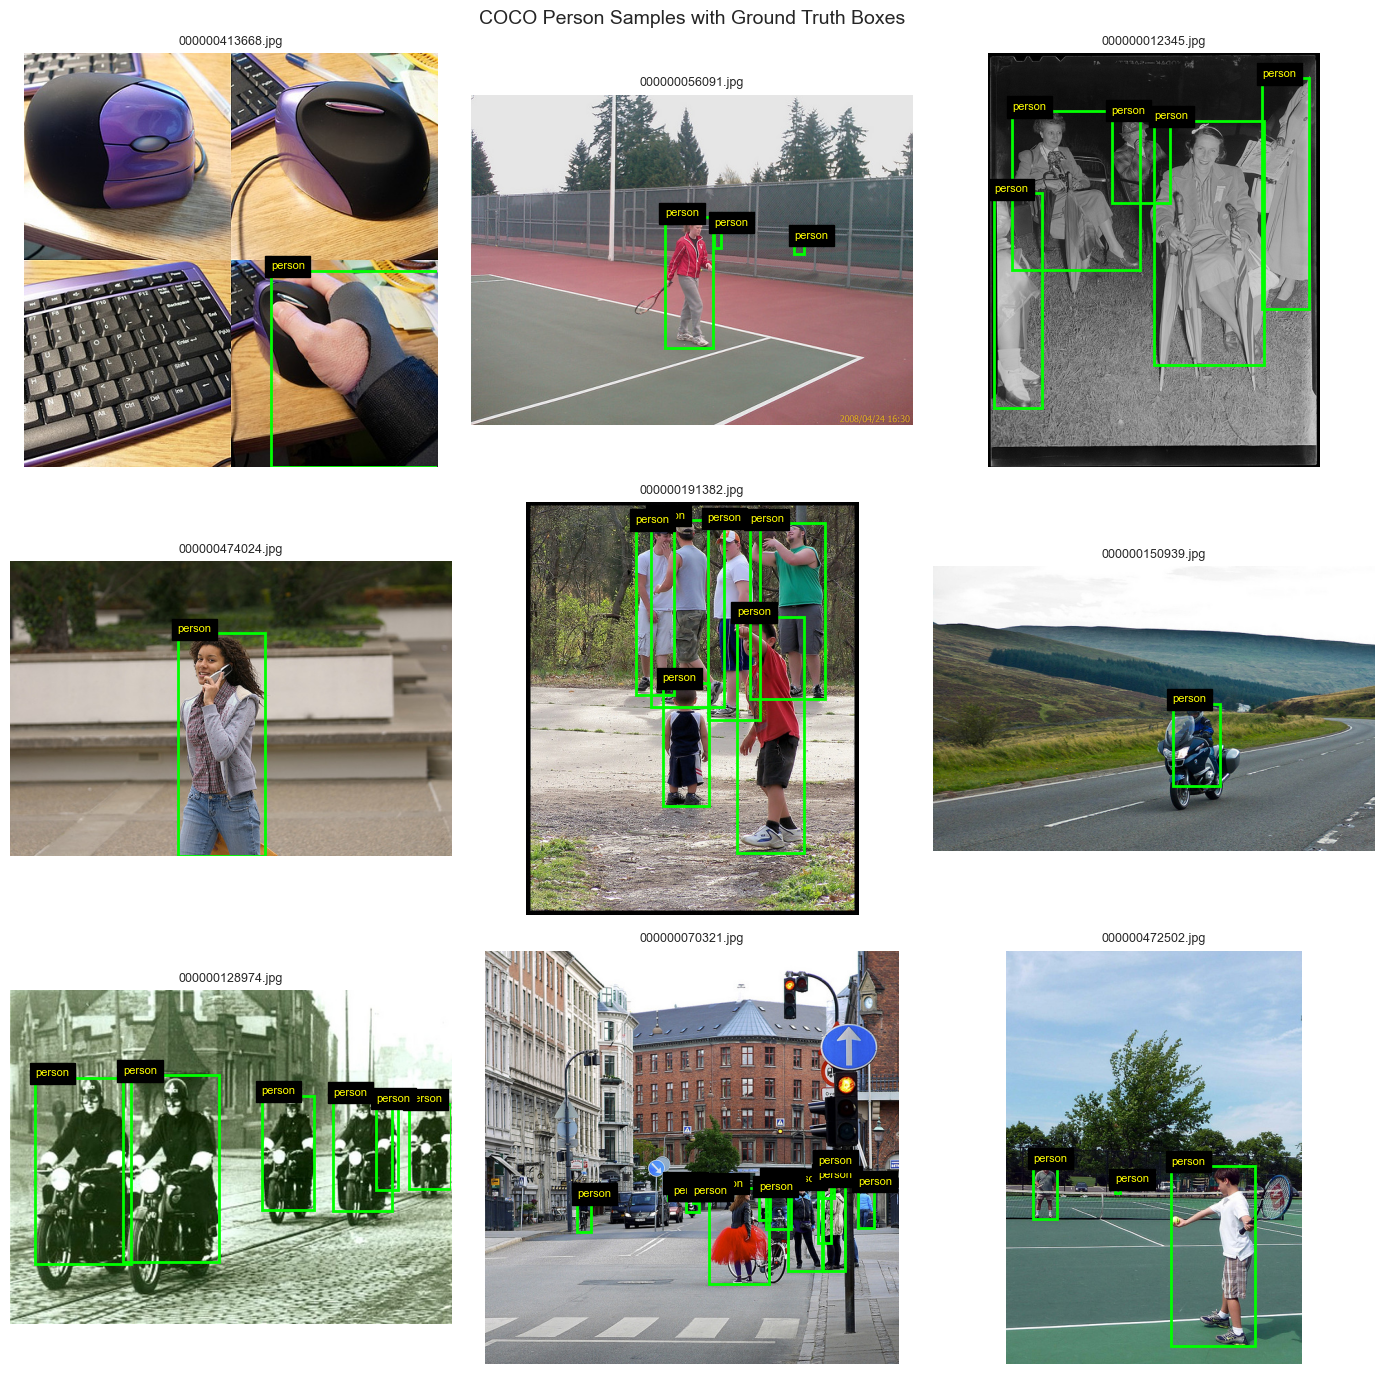

In [5]:
def read_yolo_boxes(label_path, w, h):
    boxes = []
    class_ids = []
    if not label_path.exists():
        return np.zeros((0, 4), dtype=np.float32), np.array([], dtype=np.int64)

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    for line in lines:
        cls, xc, yc, bw, bh = line.split()[:5]
        cls = int(cls)
        xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
        x1 = (xc - bw / 2.0) * w
        y1 = (yc - bh / 2.0) * h
        x2 = (xc + bw / 2.0) * w
        y2 = (yc + bh / 2.0) * h
        boxes.append([x1, y1, x2, y2])
        class_ids.append(cls)

    return np.array(boxes, dtype=np.float32), np.array(class_ids, dtype=np.int64)

train_images = sorted([p for p in TRAIN_IMAGES_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])
sample_images = random.sample(train_images, 9)

fig, axes = plt.subplots(3, 3, figsize=(14, 14))
for ax, image_path in zip(axes.flat, sample_images):
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    label_path = TRAIN_LABELS_DIR / (image_path.stem + ".txt")
    boxes, class_ids = read_yolo_boxes(label_path, w, h)

    ax.imshow(image)
    for box, class_id in zip(boxes, class_ids):
        x1, y1, x2, y2 = box
        rect = plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2, color="lime")
        ax.add_patch(rect)
        ax.text(x1, y1 - 2, CLASS_NAMES[class_id], color="yellow", fontsize=8, backgroundcolor="black")

    ax.set_title(image_path.name, fontsize=9)
    ax.axis("off")

plt.suptitle("COCO Person Samples with Ground Truth Boxes", fontsize=14)
plt.tight_layout()
plt.show()

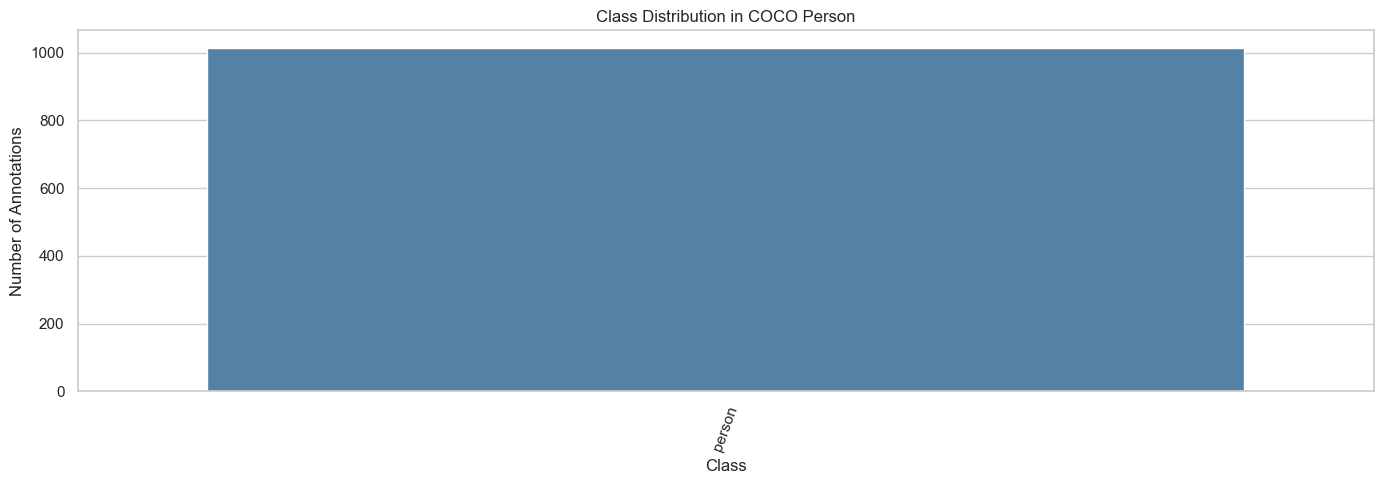

Number of images: 240
Number of classes: 1
Average boxes per image: 4.229


In [6]:
class_counts = {name: 0 for name in CLASS_NAMES}
boxes_per_image = []

for image_path in train_images:
    label_path = TRAIN_LABELS_DIR / (image_path.stem + ".txt")
    if not label_path.exists():
        boxes_per_image.append(0)
        continue

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    boxes_per_image.append(len(lines))
    for line in lines:
        cls_id = int(line.split()[0])
        class_counts[CLASS_NAMES[cls_id]] += 1

dist_df = pd.DataFrame({
    "class": list(class_counts.keys()),
    "count": list(class_counts.values())
}).sort_values("count", ascending=False)

plt.figure(figsize=(14, 5))
sns.barplot(data=dist_df, x="class", y="count", color="steelblue")
plt.title("Class Distribution in COCO Person")
plt.xlabel("Class")
plt.ylabel("Number of Annotations")
plt.xticks(rotation=70)
plt.tight_layout()
plt.show()

print("Number of images:", len(train_images))
print("Number of classes:", NUM_CLASSES)
print("Average boxes per image:", round(float(np.mean(boxes_per_image)), 3))

## 4. Dataset Verification

In [7]:
checked_images = train_images[:40]
valid_image_count = 0
valid_label_count = 0

for image_path in checked_images:
    image = Image.open(image_path).convert("RGB")
    w, h = image.size
    valid_image_count += 1

    label_path = TRAIN_LABELS_DIR / (image_path.stem + ".txt")
    if not label_path.exists():
        continue

    lines = [line.strip() for line in label_path.read_text(encoding="utf-8").splitlines() if line.strip()]
    for line in lines:
        cls, xc, yc, bw, bh = line.split()[:5]
        cls = int(cls)
        xc, yc, bw, bh = map(float, (xc, yc, bw, bh))
        assert 0 <= cls < NUM_CLASSES
        assert 0.0 <= xc <= 1.0
        assert 0.0 <= yc <= 1.0
        assert 0.0 <= bw <= 1.0
        assert 0.0 <= bh <= 1.0
    valid_label_count += 1

print("Checked images:", valid_image_count)
print("Checked label files:", valid_label_count)
print("Status: person-only YOLO labels look valid.")

Checked images: 40
Checked label files: 40
Status: person-only YOLO labels look valid.


In [8]:
RFDETR_DATASET_DIR = COCO_PERSON_ROOT

rfdetr_yaml = RFDETR_DATASET_DIR / "data.yaml"
with open(rfdetr_yaml, "w", encoding="utf-8") as f:
    f.write("names:\n")
    f.write("  0: 'person'\n")
    f.write("nc: 1\n")
    f.write("train: train/images\n")
    f.write("val: valid/images\n")

print("RF-DETR dataset directory:", RFDETR_DATASET_DIR)
print("RF-DETR YAML:", rfdetr_yaml)

RF-DETR dataset directory: /Users/brader/Desktop/ggsn/vision/data/coco_person300
RF-DETR YAML: /Users/brader/Desktop/ggsn/vision/data/coco_person300/data.yaml


In [9]:
required_paths = [
    RFDETR_DATASET_DIR / "data.yaml",
    RFDETR_DATASET_DIR / "train" / "images",
    RFDETR_DATASET_DIR / "train" / "labels",
    RFDETR_DATASET_DIR / "valid" / "images",
    RFDETR_DATASET_DIR / "valid" / "labels",
]

for p in required_paths:
    print(p, "->", p.exists())

print("Train image count:", len(list((RFDETR_DATASET_DIR / "train" / "images").glob("*.jpg"))))
print("Valid image count:", len(list((RFDETR_DATASET_DIR / "valid" / "images").glob("*.jpg"))))
print("Status: dataset is ready for RF-DETR YOLO-format training.")

/Users/brader/Desktop/ggsn/vision/data/coco_person300/data.yaml -> True
/Users/brader/Desktop/ggsn/vision/data/coco_person300/train/images -> True
/Users/brader/Desktop/ggsn/vision/data/coco_person300/train/labels -> True
/Users/brader/Desktop/ggsn/vision/data/coco_person300/valid/images -> True
/Users/brader/Desktop/ggsn/vision/data/coco_person300/valid/labels -> True
Train image count: 240
Valid image count: 60
Status: dataset is ready for RF-DETR YOLO-format training.


## 5. Fine-tuning - YOLOv8n

In [12]:
yolov8n = YOLO("yolov8n.pt")
yolov8n.train(
    data=str(COCO_PERSON_LOCAL_YAML),
    epochs=15,
    imgsz=640,
    batch=8,
    device=DEVICE,
    project=str(RUNS_ROOT),
    name="yolov8n_person300",
    exist_ok=True,
    lr0=1e-4,
    lrf=0.1,
    mosaic=0.1,
    mixup=0.0,
    close_mosaic=1,
    freeze=10,
    patience=8,
    workers=0,
)

Ultralytics 8.4.39 🚀 Python-3.10.18 torch-2.7.1 MPS (Apple M2)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=1, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/Users/brader/Desktop/ggsn/vision/data/coco_person300/coco_person300.yaml, degrees=0.0, deterministic=True, device=mps, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.1, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=0.1, multi_scale=0.0, name=yolov8n_person300, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, o

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x35a20aad0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048,    

Training is fixed to 15 epochs for both remaining models (YOLOv8n and RF-DETR-B) to keep the comparison fair.

## 6. Cleanup removed models and old artifacts

#### Medium Yolo model is too big for my MacBook :(

## 7. Fine-tuning - RF-DETR-B

In [ ]:
rfdetr_b = RFDETRBase(device=DEVICE)
rfdetr_b.train(
    dataset_dir=str(RFDETR_DATASET_DIR),
    dataset_file="roboflow",
    output_dir=str(RUNS_ROOT / "rfdetr_b_person300"),
    epochs=15,
    batch_size=1,
    grad_accum_steps=8,
    lr=1e-4,
    num_workers=0,
    device=DEVICE,
    resolution=560,
    multi_scale=False,
    expanded_scales=False,
    square_resize_div_64=True,
    use_ema=False,
    run_test=False,
    tensorboard=False,
    wandb=False,
    mlflow=False,
    progress_bar="tqdm"
)

[2026-04-19 21:37:35] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-19 21:37:37] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-19 21:37:40] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.


[2026-04-19 21:37:41] [WARNING] rf-detr - Checkpoint has 90 classes but model is configured for 1. The detection head will be re-initialized to 1 classes.
Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


[2026-04-19 21:37:41] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-04-19 21:37:41] [INFO] rf-detr - Built 1 Albumentations transforms from config
[2026-04-19 21:37:42] [INFO] rf-detr - Built 1 Albumentations transforms from config


Loading `train_dataloader` to estimate number of stepping batches.
/opt/homebrew/Caskroom/miniforge/base/envs/pytorch_env/lib/python3.10/site-packages/pytorch_lightning/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.
/opt/homebrew/Caskroom/miniforge/base/envs/pytorch_env/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name        | Type         | Params | Mode 
-----------------------------------------------------
0 | model       | LWDETR       | 31.9 M | train
1 | criterion   | SetCriterion | 0      | train
2 | postprocess | PostProcess  | 0      | train
-----------------------------------------------------
31.9 M  

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=15` reached.


[2026-04-19 23:15:48] [INFO] rf-detr - Best total checkpoint saved from regular (regular=0.5795, ema=0.0000)


## 8. Removed RF-DETR-L

RF-DETR-L training was removed to avoid out-of-memory failures on MPS.

## 9. Training Curves

In [10]:
def load_yolo_curve(csv_path):
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    df["epoch_num"] = df["epoch"] + 1
    train_cols = [c for c in df.columns if c.startswith("train/") and c.endswith("loss")]
    val_cols = [c for c in df.columns if c.startswith("val/") and c.endswith("loss")]
    df["train_loss"] = df[train_cols].sum(axis=1)
    df["val_loss"] = df[val_cols].sum(axis=1)
    df["map50"] = df["metrics/mAP50(B)"]
    return df[["epoch_num", "train_loss", "val_loss", "map50"]].copy()

def load_rfdetr_curve(csv_path):
    df = pd.read_csv(csv_path)
    df = df.groupby("epoch").mean(numeric_only=True).reset_index()
    df["epoch_num"] = df["epoch"] + 1
    out = pd.DataFrame({
        "epoch_num": df["epoch_num"],
        "train_loss": df["train/loss"],
        "val_loss": df["val/loss"],
        "map50": df["val/mAP_50"],
        "map5095": df["val/mAP_50_95"],
    })
    return out

yolov8n_curve = load_yolo_curve(RUNS_ROOT / "yolov8n_person300" / "results.csv")
rfdetr_b_curve = load_rfdetr_curve(RUNS_ROOT / "rfdetr_b_person300" / "metrics.csv")

curves = {
    "YOLOv8n": yolov8n_curve,
    "RF-DETR-B": rfdetr_b_curve,
}

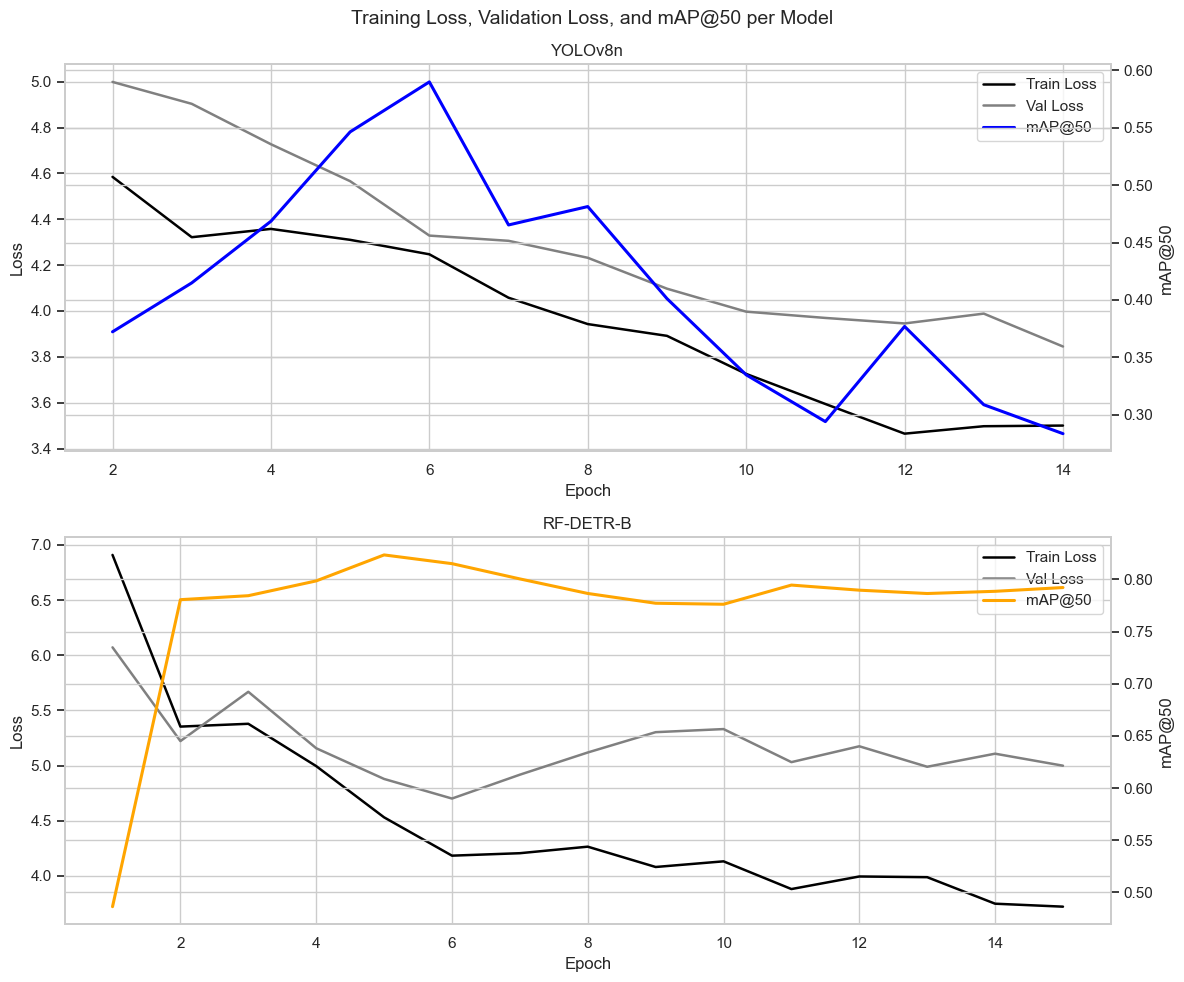

In [25]:
fig, axes = plt.subplots(2, 1, figsize=(12, 10))

for ax, (model_name, df) in zip(axes.flat, curves.items()):
    ax.plot(df["epoch_num"], df["train_loss"], label="Train Loss", color="black", linewidth=1.8)
    ax.plot(df["epoch_num"], df["val_loss"], label="Val Loss", color="gray", linewidth=1.8)
    ax2 = ax.twinx()
    ax2.plot(df["epoch_num"], df["map50"], label="mAP@50", color=MODEL_COLORS[model_name], linewidth=2.2)

    ax.set_title(model_name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax2.set_ylabel("mAP@50")

    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, loc="best")

plt.suptitle("Training Loss, Validation Loss, and mAP@50 per Model", fontsize=14)
plt.tight_layout()
plt.show()

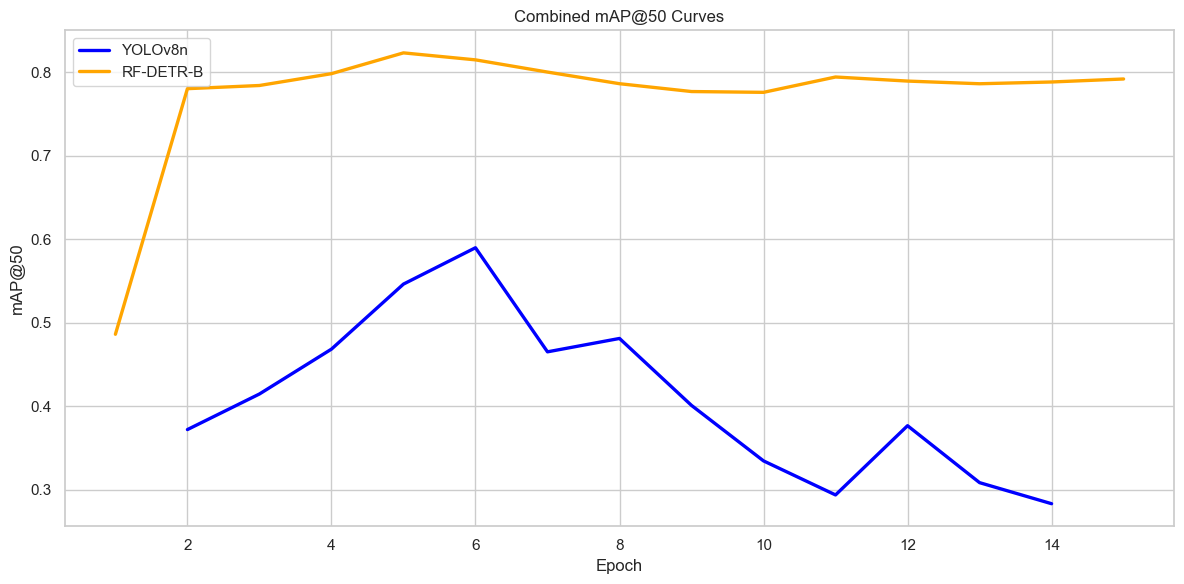

In [11]:
plt.figure(figsize=(12, 6))
for model_name, df in curves.items():
    plt.plot(df["epoch_num"], df["map50"], label=model_name, color=MODEL_COLORS[model_name], linewidth=2.4)

plt.title("Combined mAP@50 Curves")
plt.xlabel("Epoch")
plt.ylabel("mAP@50")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Inference and Latency Benchmarking (Fine-tuned vs Base)

In [13]:
YOLO_N_BEST = RUNS_ROOT / "yolov8n_person300" / "weights" / "best.pt"
RF_B_BEST = RUNS_ROOT / "rfdetr_b_person300" / "checkpoint_best_total.pth"

yolo_n_ft_infer = YOLO(str(YOLO_N_BEST))
yolo_n_base_infer = YOLO("yolov8n.pt")

# This RF-DETR version loads fine-tuned weights through `pretrain_weights`.
rfdetr_b_ft_infer = RFDETRBase(pretrain_weights=str(RF_B_BEST), device=DEVICE)
rfdetr_b_base_infer = RFDETRBase(device=DEVICE)

val_image_paths = sorted([p for p in VAL_IMAGES_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png"}])

def read_gt_boxes_tensor(label_path, w, h):
    boxes_np, _ = read_yolo_boxes(label_path, w, h)
    if len(boxes_np) == 0:
        return torch.zeros((0, 4), dtype=torch.float32)
    return torch.tensor(boxes_np, dtype=torch.float32)

def mean_iou_for_image(pred_boxes, gt_boxes):
    if pred_boxes.shape[0] == 0 or gt_boxes.shape[0] == 0:
        return 0.0
    iou_matrix = box_iou(pred_boxes, gt_boxes)
    return float(iou_matrix.max(dim=1).values.mean().item())

def _extract_rf_scores(det):
    for attr in ["confidence", "confidences", "scores", "score"]:
        if hasattr(det, attr):
            values = getattr(det, attr)
            if values is None:
                continue
            arr = np.array(values, dtype=np.float32).reshape(-1)
            if arr.size > 0:
                return arr

    if hasattr(det, "xyxy") and det.xyxy is not None:
        return np.ones((len(det.xyxy),), dtype=np.float32)

    return np.zeros((0,), dtype=np.float32)

def predict_yolo(model, img_path, conf=0.25):
    pred = model.predict(str(img_path), device=DEVICE, conf=conf, verbose=False)[0]

    if pred.boxes is None or pred.boxes.xyxy is None:
        return np.zeros((0, 4), dtype=np.float32), np.zeros((0,), dtype=np.float32)

    boxes = pred.boxes.xyxy.detach().cpu().numpy().astype(np.float32)
    if hasattr(pred.boxes, "conf") and pred.boxes.conf is not None:
        scores = pred.boxes.conf.detach().cpu().numpy().astype(np.float32)
    else:
        scores = np.ones((len(boxes),), dtype=np.float32)

    return boxes, scores

def predict_rfdetr(model, img_path, threshold=0.25):
    det = model.predict(str(img_path), threshold=threshold, include_source_image=False)

    if hasattr(det, "xyxy") and det.xyxy is not None and len(det.xyxy) > 0:
        boxes = np.array(det.xyxy, dtype=np.float32).reshape(-1, 4)
    else:
        boxes = np.zeros((0, 4), dtype=np.float32)

    scores = _extract_rf_scores(det)
    if len(scores) != len(boxes):
        scores = np.ones((len(boxes),), dtype=np.float32) if len(boxes) > 0 else np.zeros((0,), dtype=np.float32)

    return boxes, scores

def benchmark_model(predict_fn, gt_tensors_by_path, repeats=3):
    latencies = []
    ious = []

    for img_path in val_image_paths[:3]:
        predict_fn(img_path)

    for _ in range(repeats):
        for img_path in val_image_paths:
            gt = gt_tensors_by_path[img_path]

            t0 = perf_counter()
            pred_boxes_np, _ = predict_fn(img_path)
            t1 = perf_counter()
            latencies.append((t1 - t0) * 1000.0)

            pred_boxes = torch.tensor(pred_boxes_np, dtype=torch.float32) if len(pred_boxes_np) > 0 else torch.zeros((0, 4), dtype=torch.float32)
            ious.append(mean_iou_for_image(pred_boxes, gt))

    return float(np.mean(ious)), float(np.mean(latencies))

def collect_predictions_for_ap(predict_fn, gt_np_by_path):
    gt_by_image = []
    pred_records = []

    for image_idx, img_path in enumerate(val_image_paths):
        gt_np = gt_np_by_path[img_path]
        gt_by_image.append(gt_np)

        pred_boxes, pred_scores = predict_fn(img_path)
        if len(pred_boxes) == 0:
            continue

        order = np.argsort(-pred_scores)
        pred_boxes = pred_boxes[order]
        pred_scores = pred_scores[order]

        for box, score in zip(pred_boxes, pred_scores):
            pred_records.append({
                "image_idx": image_idx,
                "score": float(score),
                "box": box.astype(np.float32),
            })

    pred_records.sort(key=lambda x: x["score"], reverse=True)
    return gt_by_image, pred_records

def compute_ap_at_iou(gt_by_image, pred_records, iou_thr):
    total_gt = sum(len(gt) for gt in gt_by_image)
    if total_gt == 0 or len(pred_records) == 0:
        return 0.0

    matched = {
        i: np.zeros(len(gt_by_image[i]), dtype=bool)
        for i in range(len(gt_by_image))
    }

    tp = np.zeros(len(pred_records), dtype=np.float32)
    fp = np.zeros(len(pred_records), dtype=np.float32)

    for i, pred in enumerate(pred_records):
        image_idx = pred["image_idx"]
        gt_boxes = gt_by_image[image_idx]

        if len(gt_boxes) == 0:
            fp[i] = 1.0
            continue

        pred_box_t = torch.tensor(pred["box"][None, :], dtype=torch.float32)
        gt_t = torch.tensor(gt_boxes, dtype=torch.float32)
        ious = box_iou(pred_box_t, gt_t).squeeze(0).numpy()

        best_gt_idx = int(np.argmax(ious))
        best_iou = float(ious[best_gt_idx])

        if best_iou >= iou_thr and not matched[image_idx][best_gt_idx]:
            tp[i] = 1.0
            matched[image_idx][best_gt_idx] = True
        else:
            fp[i] = 1.0

    tp_cum = np.cumsum(tp)
    fp_cum = np.cumsum(fp)

    recall = tp_cum / (total_gt + 1e-9)
    precision = tp_cum / (tp_cum + fp_cum + 1e-9)

    recall_grid = np.linspace(0.0, 1.0, 101)
    precision_interp = np.array([
        precision[recall >= r].max() if np.any(recall >= r) else 0.0
        for r in recall_grid
    ], dtype=np.float32)

    return float(precision_interp.mean())

def compute_map_metrics(gt_by_image, pred_records):
    iou_thresholds = np.arange(0.5, 1.0, 0.05)
    aps = [compute_ap_at_iou(gt_by_image, pred_records, thr) for thr in iou_thresholds]
    return float(aps[0]), float(np.mean(aps))

def count_yolo_params(model):
    return sum(p.numel() for p in model.model.parameters()) / 1e6

def count_rfdetr_params(model):
    return sum(p.numel() for p in model.model.model.parameters()) / 1e6

gt_tensors_by_path = {}
gt_np_by_path = {}
for img_path in val_image_paths:
    image = Image.open(img_path).convert("RGB")
    w, h = image.size

    gt_t = read_gt_boxes_tensor(VAL_LABELS_DIR / (img_path.stem + ".txt"), w, h)
    gt_tensors_by_path[img_path] = gt_t
    gt_np_by_path[img_path] = gt_t.numpy().astype(np.float32) if gt_t.numel() > 0 else np.zeros((0, 4), dtype=np.float32)

model_eval_specs = [
    ("YOLOv8n (fine-tuned)", lambda p: predict_yolo(yolo_n_ft_infer, p), count_yolo_params(yolo_n_ft_infer)),
    ("YOLOv8n (base)", lambda p: predict_yolo(yolo_n_base_infer, p), count_yolo_params(yolo_n_base_infer)),
    ("RF-DETR-B (fine-tuned)", lambda p: predict_rfdetr(rfdetr_b_ft_infer, p), count_rfdetr_params(rfdetr_b_ft_infer)),
    ("RF-DETR-B (base)", lambda p: predict_rfdetr(rfdetr_b_base_infer, p), count_rfdetr_params(rfdetr_b_base_infer)),
]

rows = []
for model_name, predict_fn, params_m in model_eval_specs:
    mean_iou, avg_latency_ms = benchmark_model(predict_fn, gt_tensors_by_path, repeats=3)
    gt_by_image, pred_records = collect_predictions_for_ap(predict_fn, gt_np_by_path)
    map50, map5095 = compute_map_metrics(gt_by_image, pred_records)

    rows.append({
        "Model": model_name,
        "Params (M)": float(params_m),
        "mAP@50": float(map50),
        "mAP@50:95": float(map5095),
        "Mean IoU": float(mean_iou),
        "Avg Latency (ms)": float(avg_latency_ms),
    })

    print(
        f"{model_name}: mAP@50={map50:.4f}, mAP@50:95={map5095:.4f}, "
        f"MeanIoU={mean_iou:.4f}, Latency={avg_latency_ms:.2f} ms"
    )

benchmark_df = pd.DataFrame(rows)
benchmark_df

[2026-04-20 14:49:56] [WARNING] rf-detr - Checkpoint has 1 classes but model is configured for 90. Using checkpoint class count (1). Pass num_classes=1 to suppress this warning.


[2026-04-20 14:49:57] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
[2026-04-20 14:49:59] [INFO] rf-detr - File rf-detr-base.pth already exists with correct MD5 hash.
YOLOv8n (fine-tuned): mAP@50=0.6011, mAP@50:95=0.3410, MeanIoU=0.6002, Latency=54.17 ms


[2026-04-20 14:50:25] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
`use_return_dict` is deprecated! Use `return_dict` instead!


YOLOv8n (base): mAP@50=0.4108, mAP@50:95=0.3044, MeanIoU=0.4392, Latency=43.59 ms
RF-DETR-B (fine-tuned): mAP@50=0.7648, mAP@50:95=0.5468, MeanIoU=0.7008, Latency=134.32 ms


[2026-04-20 14:50:59] [WARNING] rf-detr - Model is not optimized for inference. Latency may be higher than expected. You can optimize the model for inference by calling model.optimize_for_inference().
[2026-04-20 14:51:00] [WARNING] rf-detr - predict() encountered class_id values out of range [0, 80): [np.int64(90)] — mapping to empty string


RF-DETR-B (base): mAP@50=0.4735, mAP@50:95=0.3625, MeanIoU=0.3801, Latency=138.13 ms


,Model,Params (M),mAP@50,mAP@50:95,Mean IoU,Avg Latency (ms)
0,YOLOv8n (fine-tuned),3.011043,0.601085,0.341044,0.600196,54.168312
1,YOLOv8n (base),3.157200,0.410775,0.304364,0.439183,43.591873
2,RF-DETR-B (fine-tuned),31.854308,0.764816,0.546830,0.700755,134.323641
3,RF-DETR-B (base),32.174530,0.473456,0.362456,0.380140,138.125446


## 11. Comparison Graphs (Fine-tuned vs Base)

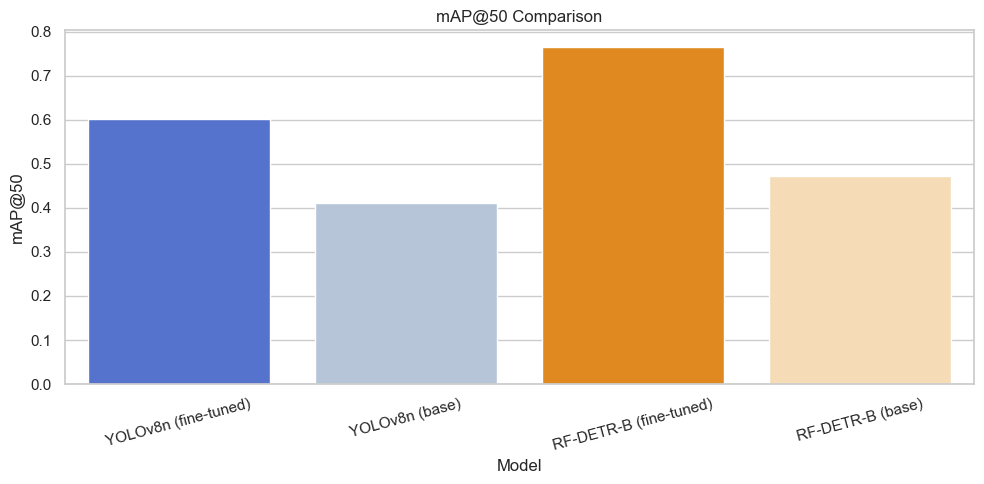

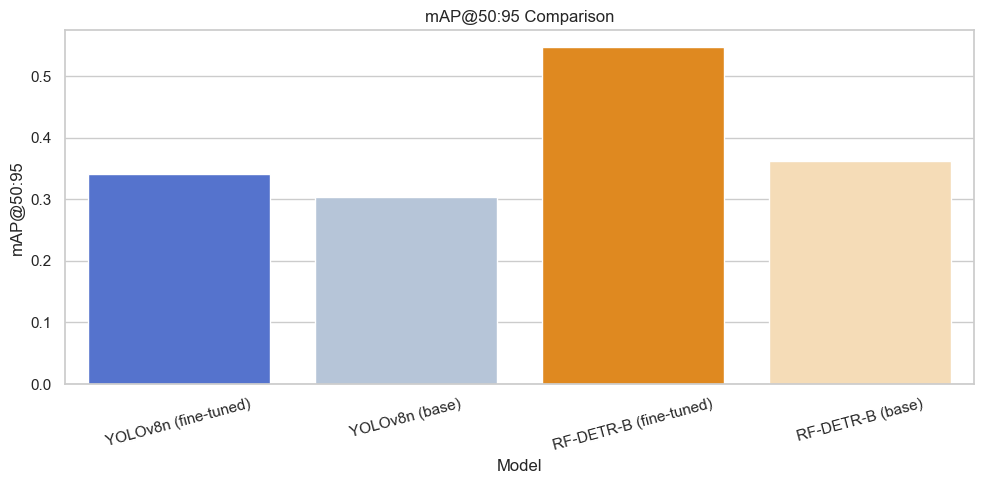

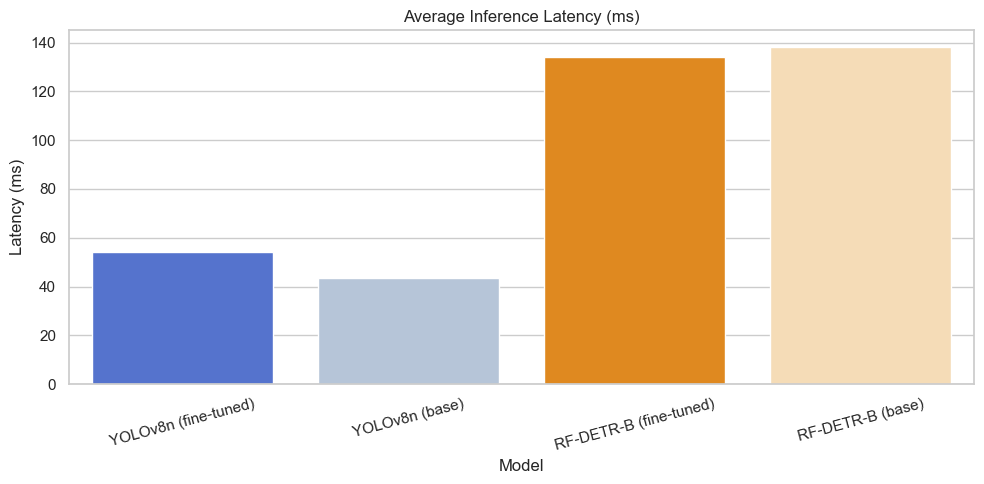

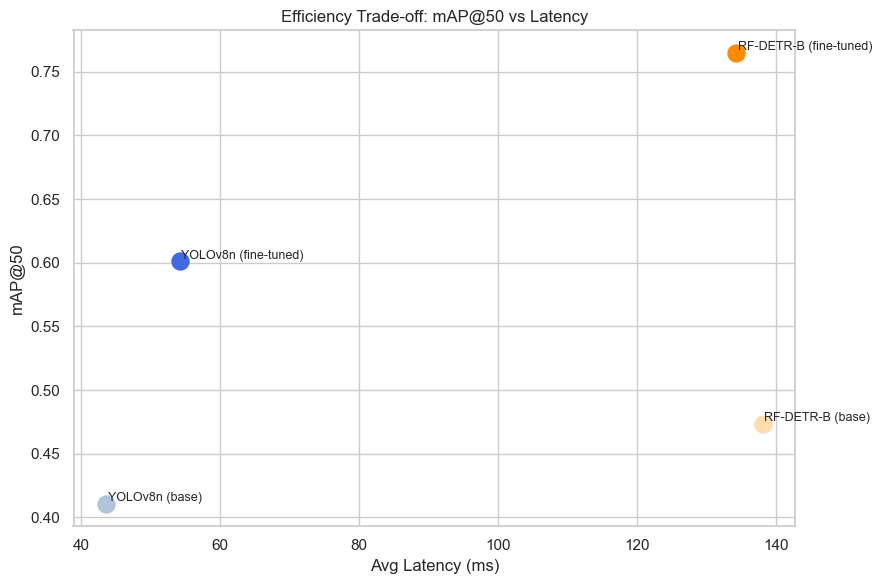

In [14]:
plot_df = benchmark_df.copy()
model_order = [
    "YOLOv8n (fine-tuned)",
    "YOLOv8n (base)",
    "RF-DETR-B (fine-tuned)",
    "RF-DETR-B (base)",
]

available_order = [m for m in model_order if m in plot_df["Model"].values]
plot_df = plot_df.set_index("Model").loc[available_order].reset_index()

comparison_colors = {
    "YOLOv8n (fine-tuned)": "royalblue",
    "YOLOv8n (base)": "lightsteelblue",
    "RF-DETR-B (fine-tuned)": "darkorange",
    "RF-DETR-B (base)": "navajowhite",
}
palette = [comparison_colors[m] for m in available_order]

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="mAP@50", hue="Model", palette=palette, legend=False)
plt.title("mAP@50 Comparison")
plt.xlabel("Model")
plt.ylabel("mAP@50")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="mAP@50:95", hue="Model", palette=palette, legend=False)
plt.title("mAP@50:95 Comparison")
plt.xlabel("Model")
plt.ylabel("mAP@50:95")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x="Model", y="Avg Latency (ms)", hue="Model", palette=palette, legend=False)
plt.title("Average Inference Latency (ms)")
plt.xlabel("Model")
plt.ylabel("Latency (ms)")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
for _, row in plot_df.iterrows():
    plt.scatter(row["Avg Latency (ms)"], row["mAP@50"], s=150, color=comparison_colors[row["Model"]])
    plt.text(row["Avg Latency (ms)"] + 0.2, row["mAP@50"] + 0.002, row["Model"], fontsize=9)

plt.title("Efficiency Trade-off: mAP@50 vs Latency")
plt.xlabel("Avg Latency (ms)")
plt.ylabel("mAP@50")
plt.tight_layout()
plt.show()

### Prediction Comparison (Tricky Cases)

- left: ground truth boxes
- middle: YOLOv8n predicted boxes
- right: RF-DETR-B predicted boxes

Selection includes:
- cases where both models struggle
- cases where YOLOv8n is worse
- cases where RF-DETR-B is worse

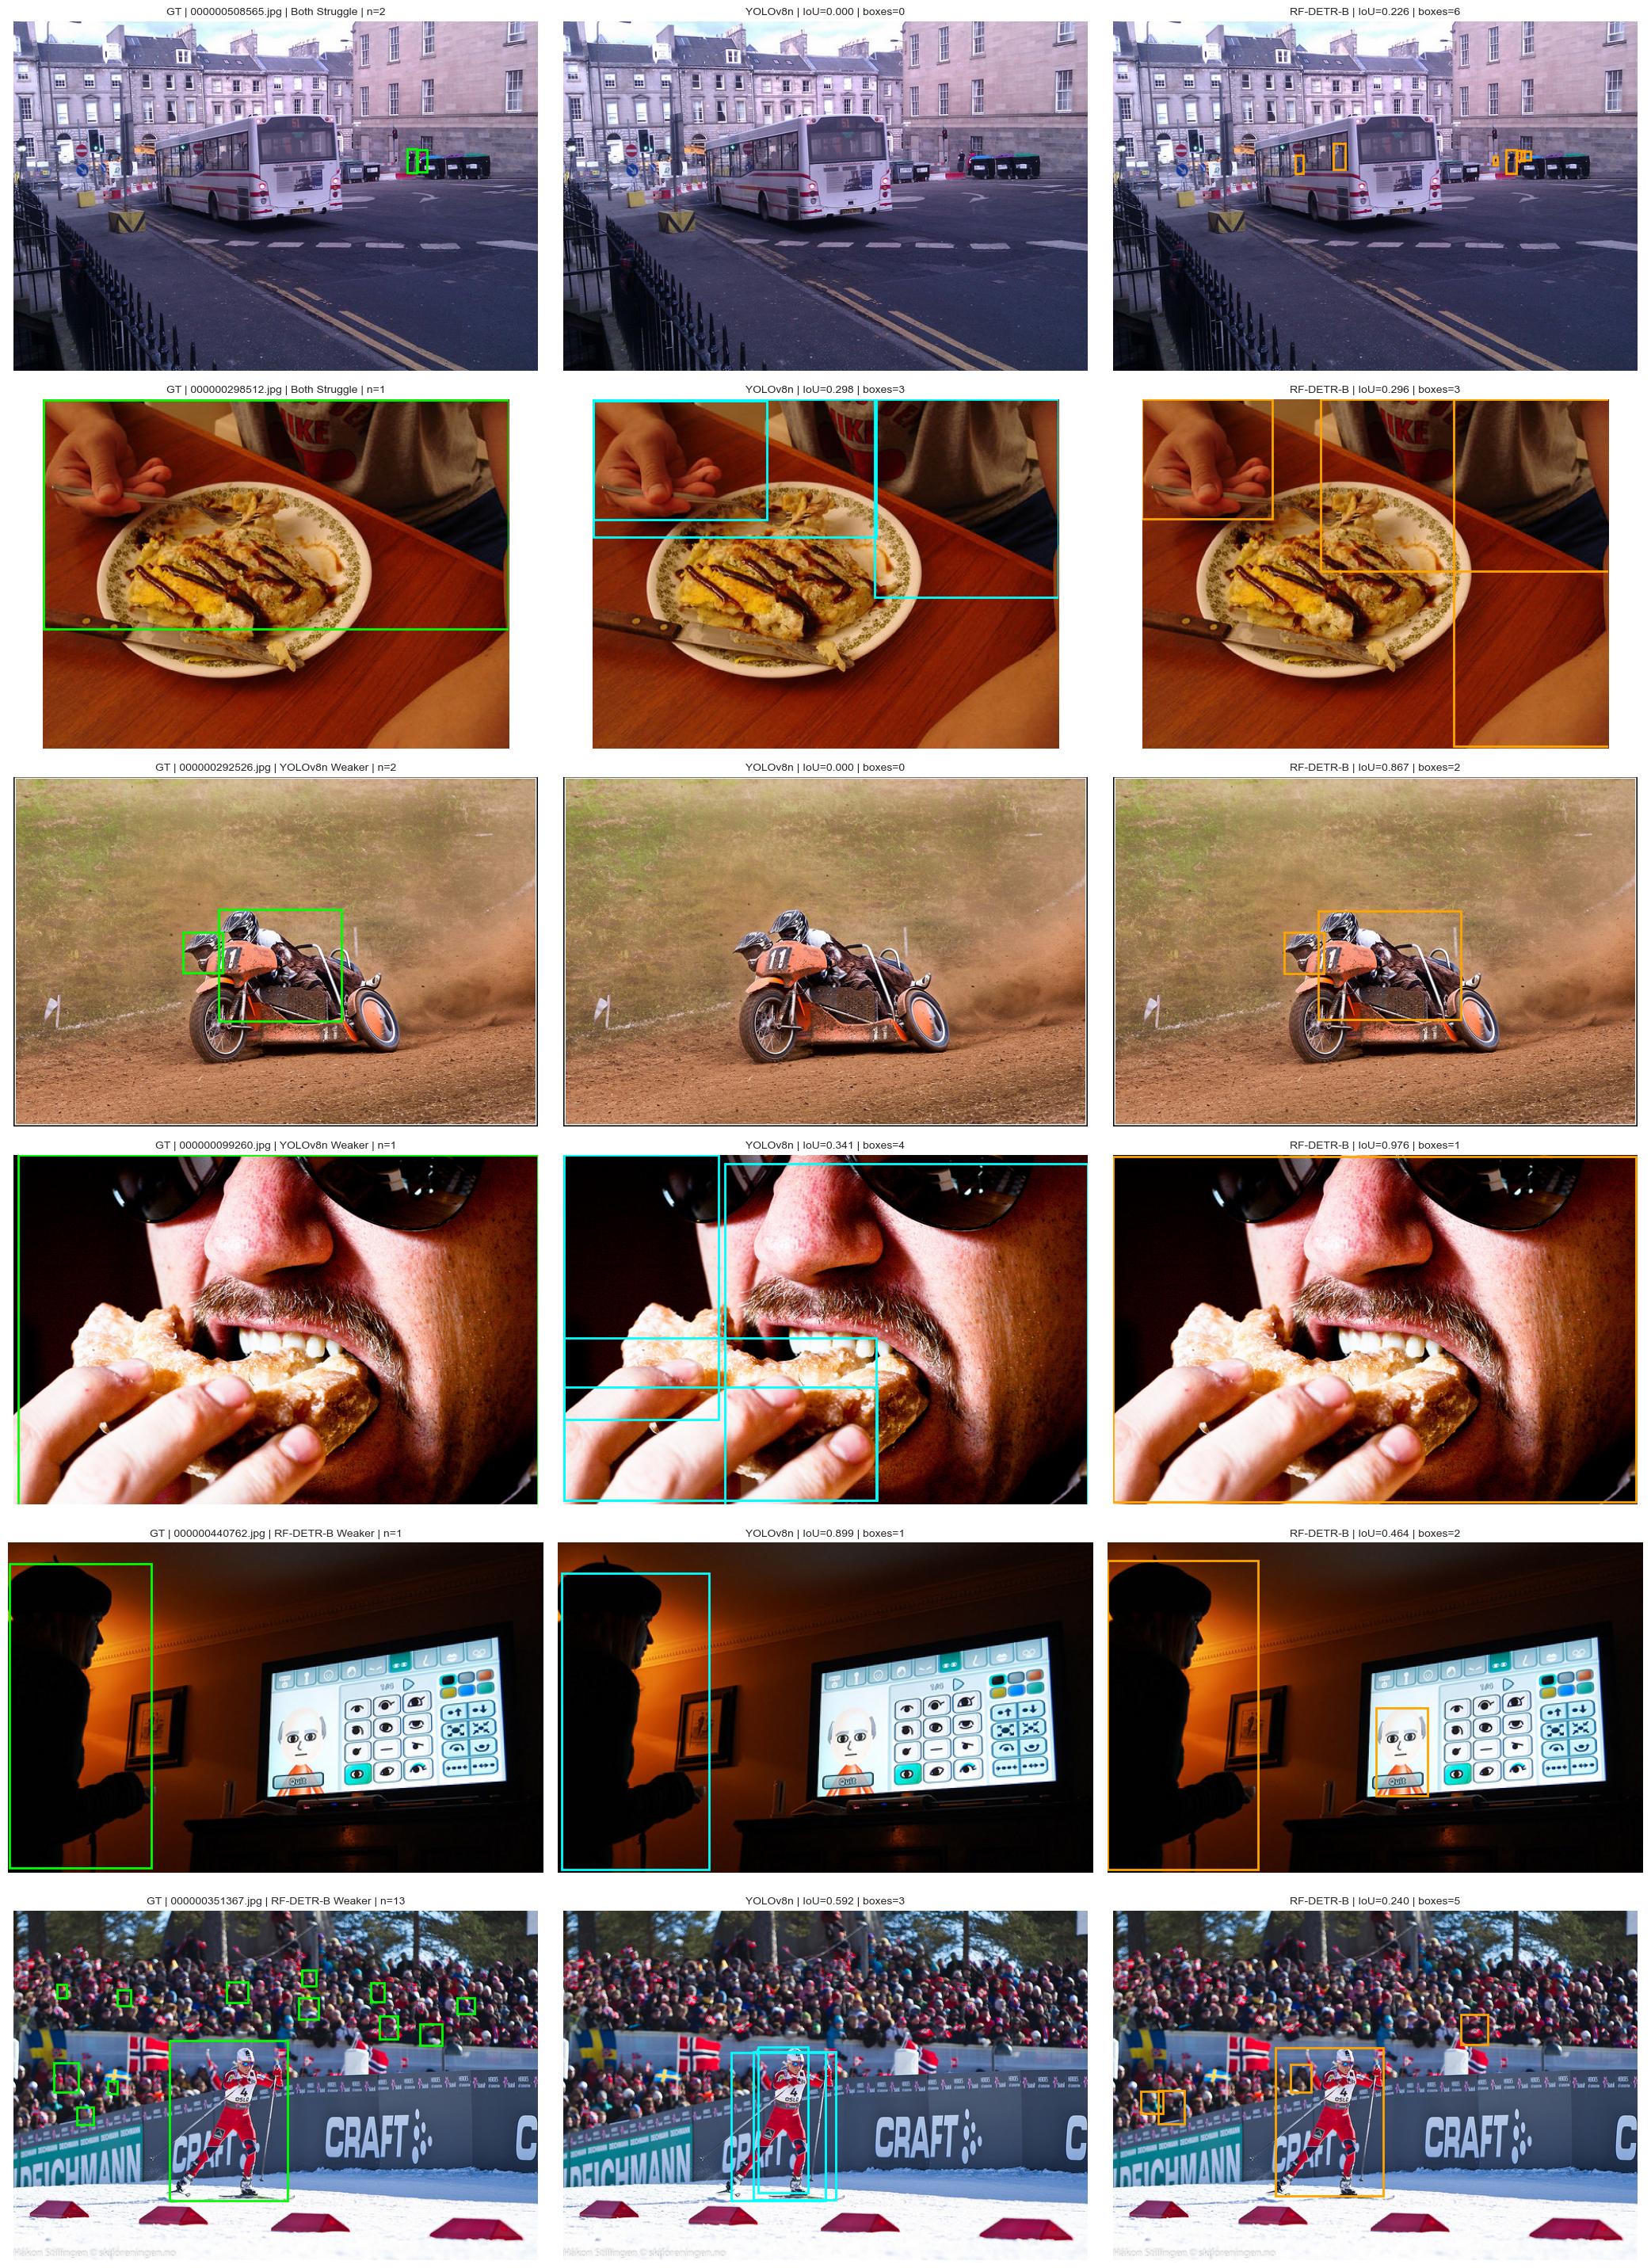

,image,yolo_iou,rf_iou,n_gt,n_yolo,n_rf,gap_rf_minus_yolo,gap_yolo_minus_rf
49,000000508565.jpg,0.000000,0.226485,2,0,6,0.226485,-0.226485
21,000000292526.jpg,0.000000,0.866786,2,0,2,0.866786,-0.866786
24,000000298512.jpg,0.298332,0.295773,1,3,3,-0.002558,0.002558
36,000000396617.jpg,0.311693,0.904740,1,2,1,0.593047,-0.593047
19,000000286411.jpg,0.337401,0.266027,3,2,5,-0.071374,0.071374
6,000000099260.jpg,0.341376,0.976056,1,4,1,0.634680,-0.634680
9,000000102037.jpg,0.355317,0.422889,13,31,22,0.067572,-0.067572
20,000000291349.jpg,0.357397,0.497731,1,2,2,0.140334,-0.140334
14,000000176324.jpg,0.360821,0.501836,13,33,23,0.141015,-0.141015
51,000000515777.jpg,0.402311,0.438994,1,3,2,0.036684,-0.036684


In [15]:
import matplotlib.patches as patches


def _to_boxes_yolo(img_path):
    pred = yolo_n_ft_infer.predict(str(img_path), device=DEVICE, conf=0.25, verbose=False)[0]
    if pred.boxes is None or pred.boxes.xyxy is None:
        return np.zeros((0, 4), dtype=np.float32)
    return pred.boxes.xyxy.detach().cpu().numpy().astype(np.float32)


def _to_boxes_rfdetr(img_path):
    det = rfdetr_b_ft_infer.predict(str(img_path), threshold=0.25, include_source_image=False)
    if hasattr(det, "xyxy") and det.xyxy is not None and len(det.xyxy) > 0:
        return np.array(det.xyxy, dtype=np.float32)
    return np.zeros((0, 4), dtype=np.float32)


def _to_boxes_gt(img_path):
    image = Image.open(img_path).convert("RGB")
    w, h = image.size
    gt_boxes, _ = read_yolo_boxes(VAL_LABELS_DIR / f"{img_path.stem}.txt", w, h)
    return gt_boxes.astype(np.float32), image


def _mean_iou_np(pred_boxes_np, gt_boxes_np):
    if len(pred_boxes_np) == 0 or len(gt_boxes_np) == 0:
        return 0.0
    pred_t = torch.tensor(pred_boxes_np, dtype=torch.float32)
    gt_t = torch.tensor(gt_boxes_np, dtype=torch.float32)
    iou_matrix = box_iou(pred_t, gt_t)
    return float(iou_matrix.max(dim=1).values.mean().item())


def _draw_boxes(ax, image, boxes, color, title):
    ax.imshow(image)
    for box in boxes:
        x1, y1, x2, y2 = box
        rect = patches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, linewidth=2, color=color)
        ax.add_patch(rect)
    ax.set_title(title, fontsize=10)
    ax.axis("off")

rows = []
for img_path in val_image_paths:
    gt_boxes, image = _to_boxes_gt(img_path)
    yolo_boxes = _to_boxes_yolo(img_path)
    rf_boxes = _to_boxes_rfdetr(img_path)

    yolo_iou = _mean_iou_np(yolo_boxes, gt_boxes)
    rf_iou = _mean_iou_np(rf_boxes, gt_boxes)

    rows.append({
        "path": img_path,
        "image": image,
        "gt_boxes": gt_boxes,
        "yolo_boxes": yolo_boxes,
        "rf_boxes": rf_boxes,
        "yolo_iou": yolo_iou,
        "rf_iou": rf_iou,
        "n_gt": len(gt_boxes),
        "n_yolo": len(yolo_boxes),
        "n_rf": len(rf_boxes),
        "max_iou": max(yolo_iou, rf_iou),
    })

cases_df = pd.DataFrame([
    {
        "image": r["path"].name,
        "yolo_iou": r["yolo_iou"],
        "rf_iou": r["rf_iou"],
        "n_gt": r["n_gt"],
        "n_yolo": r["n_yolo"],
        "n_rf": r["n_rf"],
        "gap_rf_minus_yolo": r["rf_iou"] - r["yolo_iou"],
        "gap_yolo_minus_rf": r["yolo_iou"] - r["rf_iou"],
    }
    for r in rows
])

both_fail = sorted(rows, key=lambda r: r["max_iou"])[:2]
yolo_fail = sorted(rows, key=lambda r: (r["rf_iou"] - r["yolo_iou"]), reverse=True)[:2]
rf_fail = sorted(rows, key=lambda r: (r["yolo_iou"] - r["rf_iou"]), reverse=True)[:2]

picked = []
seen = set()
for group_name, group in [
    ("Both Struggle", both_fail),
    ("YOLOv8n Weaker", yolo_fail),
    ("RF-DETR-B Weaker", rf_fail),
]:
    for r in group:
        key = r["path"].name
        if key in seen:
            continue
        seen.add(key)
        r = dict(r)
        r["tag"] = group_name
        picked.append(r)

if len(picked) == 0:
    print("No validation images available for qualitative comparison.")
else:
    fig, axes = plt.subplots(len(picked), 3, figsize=(21, 4.8 * len(picked)))
    if len(picked) == 1:
        axes = np.array([axes])

    for i, r in enumerate(picked):
        _draw_boxes(
            axes[i, 0],
            r["image"],
            r["gt_boxes"],
            color="lime",
            title=f"GT | {r['path'].name} | {r['tag']} | n={r['n_gt']}",
        )
        _draw_boxes(
            axes[i, 1],
            r["image"],
            r["yolo_boxes"],
            color="cyan",
            title=f"YOLOv8n | IoU={r['yolo_iou']:.3f} | boxes={r['n_yolo']}",
        )
        _draw_boxes(
            axes[i, 2],
            r["image"],
            r["rf_boxes"],
            color="orange",
            title=f"RF-DETR-B | IoU={r['rf_iou']:.3f} | boxes={r['n_rf']}",
        )

    plt.tight_layout()
    plt.show()

cases_df.sort_values(["yolo_iou", "rf_iou"]).head(12)

## 12. Results Summary Table

In [16]:
summary_df = benchmark_df[["Model", "Params (M)", "mAP@50", "mAP@50:95", "Mean IoU", "Avg Latency (ms)"]].copy()
summary_df["Params (M)"] = summary_df["Params (M)"].round(3)
summary_df["mAP@50"] = summary_df["mAP@50"].round(4)
summary_df["mAP@50:95"] = summary_df["mAP@50:95"].round(4)
summary_df["Mean IoU"] = summary_df["Mean IoU"].round(4)
summary_df["Avg Latency (ms)"] = summary_df["Avg Latency (ms)"].round(3)
summary_df

,Model,Params (M),mAP@50,mAP@50:95,Mean IoU,Avg Latency (ms)
0,YOLOv8n (fine-tuned),3.011,0.6011,0.3410,0.6002,54.168
1,YOLOv8n (base),3.157,0.4108,0.3044,0.4392,43.592
2,RF-DETR-B (fine-tuned),31.854,0.7648,0.5468,0.7008,134.324
3,RF-DETR-B (base),32.175,0.4735,0.3625,0.3801,138.125
